In [1]:
import sqlite3
import json
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import geodatasets
from shapely.geometry import shape
from scipy.ndimage import gaussian_filter

DB = Path('..') / 'data' / 'humans_clean.sqlite3'
conn = sqlite3.connect(str(DB))
conn.execute('PRAGMA cache_size=-500000')

world = gpd.read_file(geodatasets.data.naturalearth.land['url'])

def load_polity_geo(conn, polity_name, target_year):
    cur = conn.execute('''
        SELECT geometry FROM cliopatria_polity_periods
        WHERE polity_name = ? AND from_year <= ? AND to_year >= ?
        LIMIT 1
    ''', (polity_name, target_year, target_year))
    row = cur.fetchone()
    if row:
        return shape(json.loads(row[0]))
    return None

In [2]:
# ── Middle East: Umayyad / Abbasid caliphates ──
rows_me = conn.execute('''
    SELECT ic.impact_date, ci.name_en, ci.lat, ci.lon
    FROM individuals_cliopatria ic
    JOIN individuals_keys ik ON ic.wikidata_id = ik.wikidata_id
    JOIN cities ci ON ci.id IN (ik.birthcity_id, ik.deathcity_id)
    WHERE (ic.polity_name LIKE '%Umayyad%' OR ic.polity_name LIKE '%Abbasid%')
      AND ci.lat IS NOT NULL
      AND ic.impact_date IS NOT NULL
      AND ci.lat BETWEEN 10 AND 55
      AND ci.lon BETWEEN -10 AND 80
''').fetchall()

periods_me = {
    '656\u2013750':  (656, 750),
    '750\u2013900':  (750, 900),
    '900\u20131258': (900, 1258),
}
period_labels_me = [
    'Umayyad Caliphate\n656\u2013750',
    'Early Abbasid Caliphate\n750\u2013900',
    'Late Abbasid Caliphate\n900\u20131258',
]

data_me = {k: [] for k in periods_me}
for year, city, lat, lon in rows_me:
    for label, (y0, y1) in periods_me.items():
        if y0 <= year < y1:
            data_me[label].append((lat, lon, city))
            break

city_counts_me = {}
for label, pts in data_me.items():
    counter = Counter()
    for lat, lon, city in pts:
        counter[(lat, lon, city)] += 1
    city_counts_me[label] = counter

geos_me = [
    load_polity_geo(conn, 'Umayyad Caliphate', 720),
    load_polity_geo(conn, 'Abbasid Caliphate', 800),
    load_polity_geo(conn, 'Abbasid Caliphate', 935),
]

for label, pts in data_me.items():
    print(f'{label}: {len(pts)} individual-city pairs')

656–750: 507 individual-city pairs
750–900: 864 individual-city pairs
900–1258: 380 individual-city pairs


In [3]:
# ── Chinese world: Tang / Song / Ming ──
rows_cn = conn.execute('''
    SELECT ic.impact_date, ci.name_en, ci.lat, ci.lon, ic.polity_name
    FROM individuals_cliopatria ic
    JOIN individuals_keys ik ON ic.wikidata_id = ik.wikidata_id
    JOIN cities ci ON ci.id IN (ik.birthcity_id, ik.deathcity_id)
    WHERE (
        (ic.polity_name LIKE '%Tang Dynasty%'
         AND ic.polity_name NOT LIKE '%Later Tang%'
         AND ic.polity_name NOT LIKE '%Southern Tang%')
        OR (ic.polity_name LIKE '%Song%'
            AND ic.polity_name NOT LIKE '%Songhai%'
            AND ic.polity_name NOT LIKE '%Liu Song%')
        OR ic.polity_name = 'Ming Dynasty'
    )
    AND ci.lat IS NOT NULL
    AND ic.impact_date IS NOT NULL
    AND ci.lat BETWEEN 15 AND 55
    AND ci.lon BETWEEN 70 AND 140
''').fetchall()

periods_cn = {
    '618\u2013907':   (618, 907),
    '960\u20131279':  (960, 1279),
    '1368\u20131644': (1368, 1644),
}
period_labels_cn = [
    'Tang Dynasty\n618\u2013907',
    'Song Dynasty\n960\u20131279',
    'Ming Dynasty\n1368\u20131644',
]

def classify_cn(year, polity_name):
    if 618 <= year <= 907 and 'Tang' in polity_name:
        return '618\u2013907'
    if 960 <= year <= 1279 and 'Song' in polity_name:
        return '960\u20131279'
    if 1368 <= year <= 1644 and polity_name == 'Ming Dynasty':
        return '1368\u20131644'
    return None

merge_map = {
    "Chang'an County": "Chang'an",
    "Luoyang County": "Luoyang",
    "Taiyuan County": "Taiyuan",
}
canonical_coords = {
    "Chang'an": (34.3, 108.9),
    "Luoyang": (34.7, 112.5),
    "Taiyuan": (37.9, 112.5),
}

data_cn = {k: [] for k in periods_cn}
for year, city, lat, lon, polity in rows_cn:
    p = classify_cn(year, polity)
    if p:
        data_cn[p].append((lat, lon, city))

city_counts_cn = {}
for label, pts in data_cn.items():
    counter = Counter()
    for lat, lon, city in pts:
        city_m = merge_map.get(city, city)
        if city_m in canonical_coords:
            lat, lon = canonical_coords[city_m]
        counter[(lat, lon, city_m)] += 1
    city_counts_cn[label] = counter

geos_cn = [
    load_polity_geo(conn, 'Tang Dynasty', 750),
    load_polity_geo(conn, 'Northern Song', 1000),
    load_polity_geo(conn, 'Ming Dynasty', 1500),
]

for label, pts in data_cn.items():
    print(f'{label}: {len(pts)} individual-city pairs')

conn.close()

618–907: 1135 individual-city pairs
960–1279: 322 individual-city pairs
1368–1644: 765 individual-city pairs


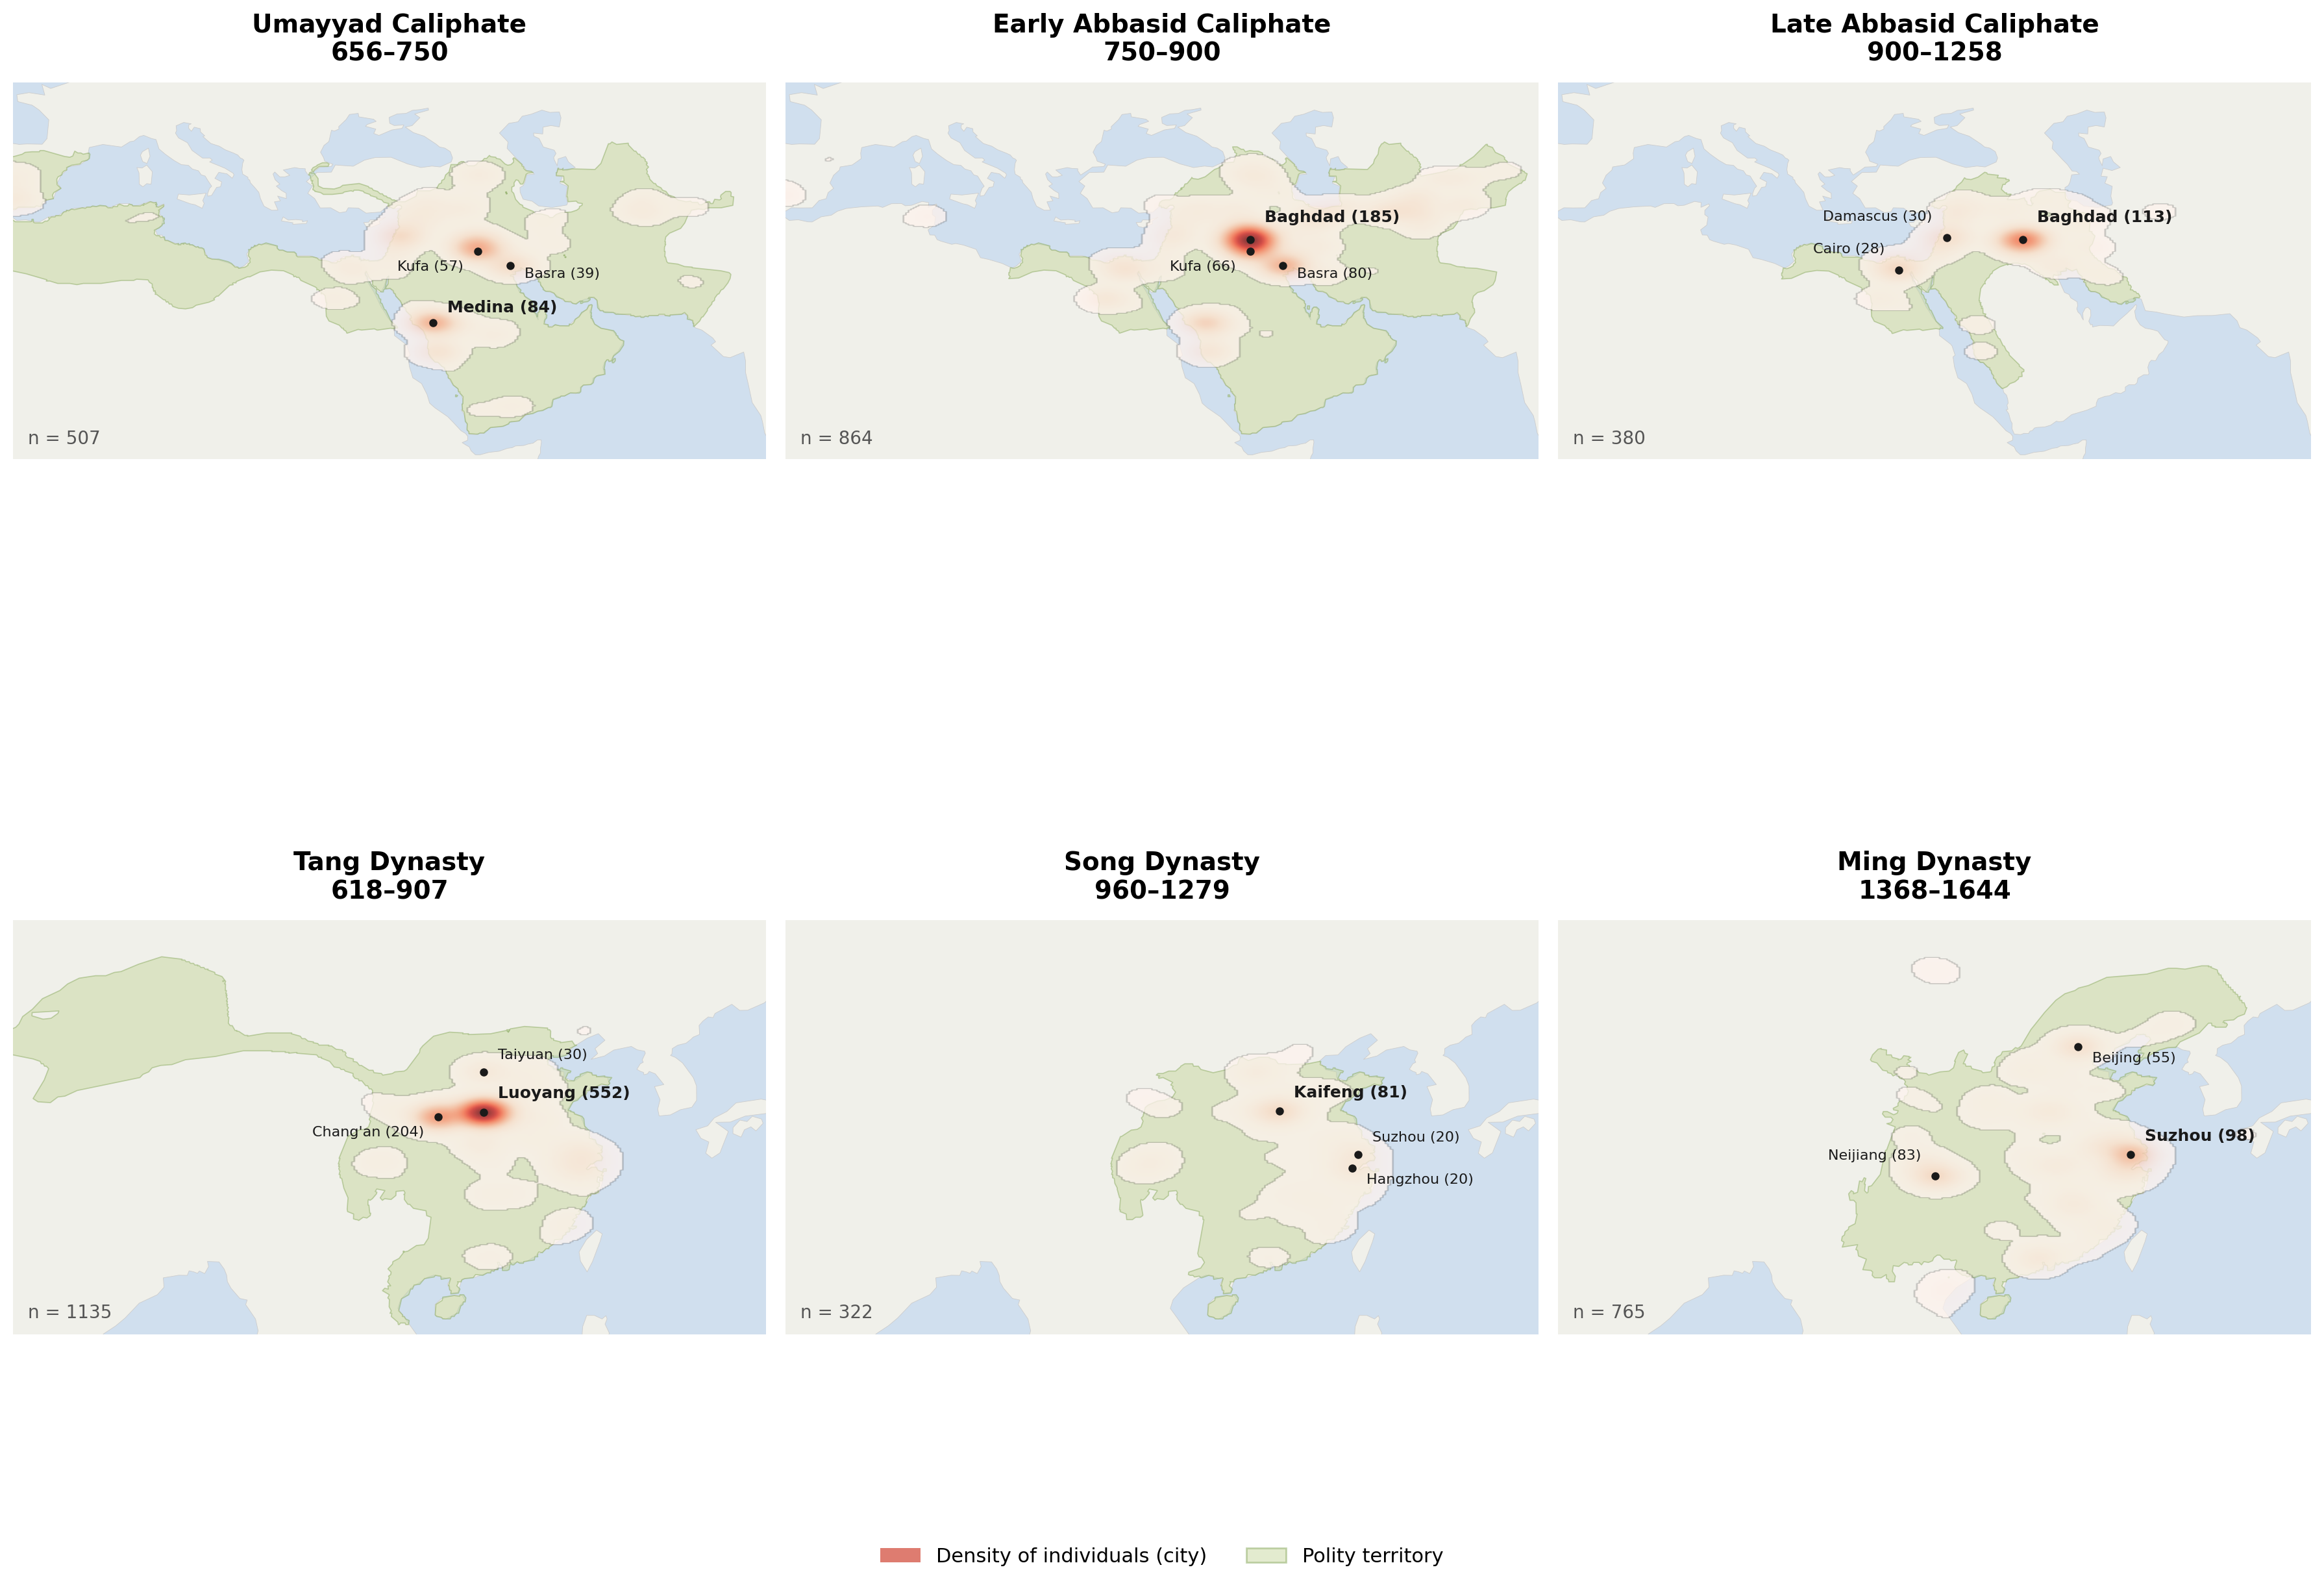

In [4]:
# ── Combined figure: 2 rows x 3 columns ──
polity_color = '#c8d8a0'
land_color = '#f0f0ea'
sea_color = '#d0dfee'
grid_res = 300

ME_EXTENT = (-5, 75, 10, 50)
CN_EXTENT = (75, 135, 17, 50)

# Per-city label offsets
offsets_me = {
    'Medina': (8, 4), 'Kufa': (-8, -12), 'Basra': (8, -8),
    'Damascus': (-8, 8), 'Baghdad': (8, 8), 'Cairo': (-8, 8),
    'Samarra': (8, 8), 'Karbala': (-8, -12),
}
ha_me = {'Kufa': 'right', 'Damascus': 'right', 'Cairo': 'right', 'Karbala': 'right'}

offsets_cn = {
    "Chang'an": (-8, -12), 'Luoyang': (8, 6), 'Taiyuan': (8, 6),
    'Kaifeng': (8, 6), 'Hangzhou': (8, -10), 'Suzhou': (8, 6),
    'Beijing': (8, -10), 'Nanjing': (8, -10), 'Neijiang': (-8, 8),
    'Guangzhou': (8, -10), 'Chengdu': (-8, 8),
}
ha_cn = {"Chang'an": 'right', 'Neijiang': 'right', 'Chengdu': 'right'}


def compute_densities(data_dict, extent, merge_map=None, canonical_coords=None):
    lon_min, lon_max, lat_min, lat_max = extent
    densities = []
    for pkey in data_dict:
        pts = data_dict[pkey]
        merged = []
        for lat, lon, city in pts:
            if merge_map:
                city = merge_map.get(city, city)
                if canonical_coords and city in canonical_coords:
                    lat, lon = canonical_coords[city]
            merged.append((lat, lon))
        lats = np.array([p[0] for p in merged]) if merged else np.array([])
        lons = np.array([p[1] for p in merged]) if merged else np.array([])
        d, _, _ = np.histogram2d(lons, lats, bins=[grid_res, grid_res],
                                 range=[[lon_min, lon_max], [lat_min, lat_max]])
        d = gaussian_filter(d.T, sigma=6)
        densities.append(d)
    vmax = max(d.max() for d in densities)
    return densities, vmax


def draw_row(axes, data_dict, city_counts, period_labels, geos, extent,
             densities, vmax, offsets, ha_map):
    lon_min, lon_max, lat_min, lat_max = extent
    period_keys = list(data_dict.keys())

    for idx, (ax, pkey, plabel, geo, density) in enumerate(
            zip(axes, period_keys, period_labels, geos, densities)):
        ax.set_facecolor(sea_color)
        world.plot(ax=ax, color=land_color, edgecolor='#cccccc', linewidth=0.3)

        if geo is not None:
            gpd.GeoSeries([geo]).plot(ax=ax, color=polity_color,
                                      edgecolor='#8aaa60', linewidth=0.6, alpha=0.5)

        density_masked = np.ma.masked_where(density < 0.01, density)
        ax.imshow(density_masked, extent=[lon_min, lon_max, lat_min, lat_max],
                  origin='lower', aspect='auto', cmap='Reds', alpha=0.75,
                  vmin=0, vmax=vmax, zorder=4, interpolation='bilinear')

        counter = city_counts[pkey]
        top3 = counter.most_common(3)
        for rank, ((clat, clon, cname), cnt) in enumerate(top3):
            dx, dy = offsets.get(cname, (8, 6))
            ha = ha_map.get(cname, 'left')
            fw = 'bold' if rank == 0 else 'normal'
            fs = 9 if rank == 0 else 8
            ax.plot(clon, clat, 'o', color='#1a1a1a', markersize=3.5, zorder=11)
            ax.annotate(f'{cname} ({cnt})', (clon, clat),
                        fontsize=fs, fontweight=fw, color='#1a1a1a',
                        ha=ha, va='bottom',
                        xytext=(dx, dy), textcoords='offset points', zorder=12)

        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.set_aspect('equal')
        ax.set_title(plabel, fontsize=14, fontweight='bold', color='black',
                     loc='center', pad=12)
        n = len(data_dict[pkey])
        ax.text(0.02, 0.03, f'n = {n}', transform=ax.transAxes,
                fontsize=10, color='#555555', va='bottom')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)


# Compute densities
dens_me, vmax_me = compute_densities(data_me, ME_EXTENT)
dens_cn, vmax_cn = compute_densities(data_cn, CN_EXTENT, merge_map, canonical_coords)

# Draw
fig, axes = plt.subplots(2, 3, figsize=(18, 13), dpi=200)

draw_row(axes[0], data_me, city_counts_me, period_labels_me, geos_me,
         ME_EXTENT, dens_me, vmax_me, offsets_me, ha_me)
draw_row(axes[1], data_cn, city_counts_cn, period_labels_cn, geos_cn,
         CN_EXTENT, dens_cn, vmax_cn, offsets_cn, ha_cn)

legend_elements = [
    mpatches.Patch(facecolor='#d45040', alpha=0.75, label='Density of individuals (city)'),
    mpatches.Patch(facecolor=polity_color, edgecolor='#8aaa60',
                   alpha=0.5, label='Polity territory'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.subplots_adjust(bottom=0.04, hspace=0.15)
plt.show()